<center>

# Handling Missing Values

<center>

##### Kiana Ghamsari

---

* `Missing values` are a common issue in `datasets`, arising from `human error`, `system glitches`, `privacy concerns`, or the `challenges of acquiring complete data`, which can sometimes be costly, time-consuming, or even impossible. For example:

    - Processing historical records that may be incomplete or damaged.



<br>

<center>

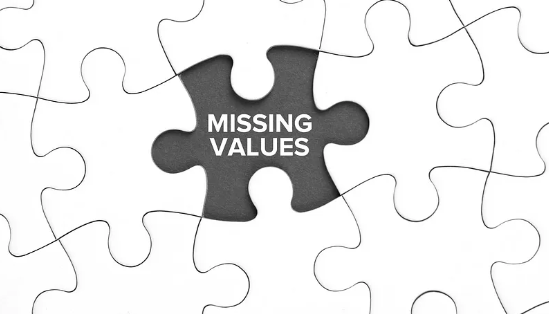

* If left unaddressed, they can reduce the sample size, distort our insights, bias our models, and ultimately lead to incorrect conclusions. They result in incomplete information and potentially harm the accuracy and dependability of your models in machine learning.

### What is a Missing Value?

* Missing values are `data points` that are absent for a specific variable in a dataset. They can be represented in various ways, such as `blank cells`, `null values`, or special symbols like `“NA”` or `“unknown”`.

<center>

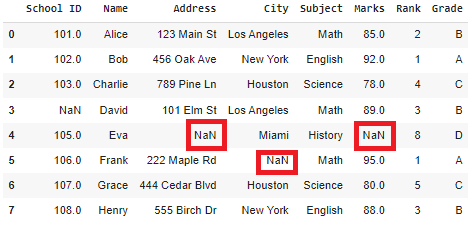

<center>

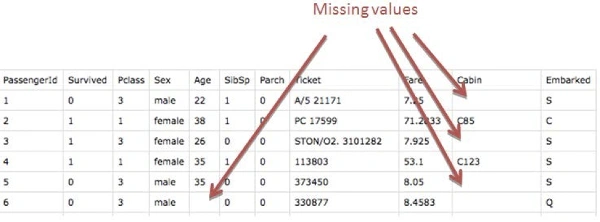

---

* Understanding the cause of missing data helps choose appropriate handling strategies and ensure the quality of your analysis.

### **It’s important to understand the reasons behind missing data:**

* **Identifying the `type of missing data`:** Is it Missing Completely at Random `(MCAR)`, Missing at Random `(MAR)`, or Missing Not at Random `(MNAR)`?

* **Evaluating the impact of missing data:** Is the missingness causing bias or affecting the analysis?

* **Choosing appropriate handling strategies:** Different techniques are suitable for different types of missing data.

### **Types of Missing Data**


<center>

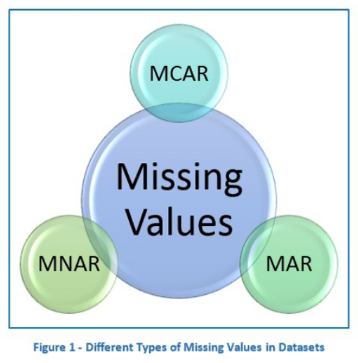
</center>

<br>

1. **MCAR (Missing Completely at Random):**  

   The missing data has no relationship with any other data in the dataset.  

   - **Example:** A survey respondent skips a question purely by accident.

   <br>

2. **MAR (Missing at Random):**  

   The missing data is related to observed data but not to the missing data itself.  

   - **Example:** High-income individuals are less likely to disclose their salaries in a survey.

   <br>

3. **MNAR (Missing Not at Random):**  

   The missing data depends on the value of the missing data itself.  

   - **Example:** People with poor health are less likely to respond to health-related surveys.  

   <br>


* This categorization helps in deciding how to `handle missing values` effectively.

---

### **Methods for Identifying Missing Data**



| **Function**         | **Description**                                                                                                     | **Example Code**                                                                                       |
|-----------------------|---------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------|
| **`.isnull()`**       | Identifies missing values in a Series or DataFrame.                                                                | `df.isnull()`                                                                                          |
| **`.notnull()`**      | Checks for non-missing values in a Series or DataFrame. Returns True for non-missing values and False otherwise.    | `df.notnull()`                                                                                        |
| **`.info()`**         | Displays information about the DataFrame, including data types, memory usage, and missing values.                 | `df.info()`                                                                                           |
| **`.isna()`**         | Identifies missing values, similar to `.isnull()`.                                                                | `df.isna()`                                                                                           |
| **`.dropna()`**       | Drops rows or columns containing missing values based on custom criteria.                                          | `df.dropna(axis=0)`                                                                                    |
| **`.fillna()`**       | Fills missing values with specific values, means, medians, or other calculated values.                            | `df.fillna(value=0)`                                                                                  |
| **`.replace()`**      | Replaces specific values with other values, facilitating data correction and standardization.                     | `df.replace('?', np.nan)`                                                                             |
| **`.drop_duplicates()`** | Removes duplicate rows based on specified columns.                                                              | `df.drop_duplicates()`                                                                                |
| **`.unique()`**       | Finds unique values in a Series or DataFrame.                                                                     | `df['column_name'].unique()`                                                                          |



In [1]:
import pandas as pd
import numpy as np

In [2]:
# Example DataFrame
data = {
    'A': [1, 2, np.nan, 4],
    'B': [np.nan, 2, 2, 4],
    'C': [1, 1, 1, 1]
}

In [3]:
df = pd.DataFrame(data)
df

,A,B,C
0,1.0,NaN,1
1,2.0,2.0,1
2,NaN,2.0,1
3,4.0,4.0,1


In [4]:
# .isnull()
print("Identify missing values:\n", df.isnull())

Identify missing values:
        A      B      C
0  False   True  False
1  False  False  False
2   True  False  False
3  False  False  False


In [5]:
# .notnull()
print("\nCheck non-missing values:\n", df.notnull())


Check non-missing values:
        A      B     C
0   True  False  True
1   True   True  True
2  False   True  True
3   True   True  True


In [6]:
# .info()
print("\nDataFrame info:\n")
df.info()


DataFrame info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       3 non-null      float64
 1   B       3 non-null      float64
 2   C       4 non-null      int64  
dtypes: float64(2), int64(1)
memory usage: 224.0 bytes


In [7]:
# .isna()
print("\nIdentify missing values (similar to isnull):\n", df.isna())


Identify missing values (similar to isnull):
        A      B      C
0  False   True  False
1  False  False  False
2   True  False  False
3  False  False  False


In [8]:
# .dropna()
print("\nDrop rows with missing values:\n", df.dropna())


Drop rows with missing values:
      A    B  C
1  2.0  2.0  1
3  4.0  4.0  1


In [9]:
# .fillna()
print("\nFill missing values with 0:\n", df.fillna(0))


Fill missing values with 0:
      A    B  C
0  1.0  0.0  1
1  2.0  2.0  1
2  0.0  2.0  1
3  4.0  4.0  1


In [10]:
# .replace()
print("\nReplace NaN with 'Missing':\n", df.replace(np.nan, 'Missing'))


Replace NaN with 'Missing':
          A        B  C
0      1.0  Missing  1
1      2.0      2.0  1
2  Missing      2.0  1
3      4.0      4.0  1


In [11]:
# .drop_duplicates()
print("\nDrop duplicate rows:\n", df.drop_duplicates())


Drop duplicate rows:
      A    B  C
0  1.0  NaN  1
1  2.0  2.0  1
2  NaN  2.0  1
3  4.0  4.0  1


In [12]:
# .unique()
print("\nFind unique values in column 'B':\n", df['B'].unique())


Find unique values in column 'B':
 [nan  2.  4.]


---

## **Effective Strategies for Handling Missing Values in Data Analysis**

### **1. Deletion Techniqus**


- **Description:** Remove rows or columns with missing data.  
- **When to Use:**  
  - The proportion of missing data is small.  
  - The missing data is randomly distributed (MCAR).  
- **Examples:**  
  - *Listwise Deletion:* Drop rows with any missing values.  
  - *Column Deletion:* Drop columns with a high proportion of missing values.  
- **Pros:** Simple and quick.  
- **Cons:** Reduces the dataset size and may introduce bias.


#### **Creating a Sample Dataframe:**

In [13]:
import pandas as pd
import numpy as np

# Creating a sample DataFrame with missing values
data = {
    'School ID': [101, 102, 103, np.nan, 105, 106, 107, 108],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank', 'Grace', 'Henry'],
    'Address': ['123 Main St', '456 Oak Ave', '789 Pine Ln', '101 Elm St', np.nan, '222 Maple Rd', '444 Cedar Blvd', '555 Birch Dr'],
    'City': ['Los Angeles', 'New York', 'Houston', 'Los Angeles', 'Miami', np.nan, 'Houston', 'New York'],
    'Subject': ['Math', 'English', 'Science', 'Math', 'History', 'Math', 'Science', 'English'],
    'Marks': [85, 92, 78, 89, np.nan, 95, 80, 88],
    'Rank': [2, 1, 4, 3, 8, 1, 5, 3],
    'Grade': ['B', 'A', 'C', 'B', 'D', 'A', 'C', 'B']
}

df = pd.DataFrame(data)
print("\nSample DataFrame:\n")

print(df)



Sample DataFrame:

   School ID     Name         Address         City  Subject  Marks  Rank Grade
0      101.0    Alice     123 Main St  Los Angeles     Math   85.0     2     B
1      102.0      Bob     456 Oak Ave     New York  English   92.0     1     A
2      103.0  Charlie     789 Pine Ln      Houston  Science   78.0     4     C
3        NaN    David      101 Elm St  Los Angeles     Math   89.0     3     B
4      105.0      Eva             NaN        Miami  History    NaN     8     D
5      106.0    Frank    222 Maple Rd          NaN     Math   95.0     1     A
6      107.0    Grace  444 Cedar Blvd      Houston  Science   80.0     5     C
7      108.0    Henry    555 Birch Dr     New York  English   88.0     3     B


In [14]:
# Removing rows with missing values
df_cleaned = df.dropna()

# Displaying the DataFrame after removing missing values
print("\nDataFrame after removing rows with missing values:\n")
print(df_cleaned)


DataFrame after removing rows with missing values:

   School ID     Name         Address         City  Subject  Marks  Rank Grade
0      101.0    Alice     123 Main St  Los Angeles     Math   85.0     2     B
1      102.0      Bob     456 Oak Ave     New York  English   92.0     1     A
2      103.0  Charlie     789 Pine Ln      Houston  Science   78.0     4     C
6      107.0    Grace  444 Cedar Blvd      Houston  Science   80.0     5     C
7      108.0    Henry    555 Birch Dr     New York  English   88.0     3     B


---

### **2. Imputation Techniques**

* **Definition of Imputation:** Imputation refers to the process of replacing missing data with substituted values to maintain the integrity of the dataset.


| **Category**              | **Technique**            | **Description**                                                                 | **Example Code**                                 |
|----------------------------|--------------------------|---------------------------------------------------------------------------------|-------------------------------------------------|
| **Simple Imputation**      | **Mean Imputation**      | Replace missing values with the column mean.                                   | `df['col'] = df['col'].fillna(df['col'].mean())` |
|                            | **Median Imputation**    | Replace missing values with the column median, effective for skewed data.      | `df['col'] = df['col'].fillna(df['col'].median())` |
|                            | **Mode Imputation**      | Replace missing values with the most frequent value in the column.             | `df['col'] = df['col'].fillna(df['col'].mode()[0])` |
| **Advanced Imputation**    | **KNN Imputation**       | Uses the mean or weighted mean of k-nearest neighbors to impute values.        | `from sklearn.impute import KNNImputer`         |
|                            | **Regression Imputation**| Predicts missing values using a regression model trained on other columns.     | Custom implementation using sklearn.            |
|                            | **Iterative Imputation** | Models each column iteratively as a function of others to impute values.       | `from sklearn.experimental import IterativeImputer` |
|                            | **Random Imputation**    | Fills missing values by randomly sampling from non-missing values in the column. | `df['col'] = df['col'].sample().values[0]`      |
|                            | **Multiple Imputation**  | Generates multiple imputations and combines results for robust analysis.       | Use `statsmodels` or `fancyimpute` libraries.   |
| **Time-Series Methods**    | **Forward Fill (FFill)** | Replaces missing values with the most recent previous non-missing value.       | `df['col'] = df['col'].fillna(method='ffill')`  |
|                            | **Backward Fill (BFill)**| Replaces missing values with the next known non-missing value.                 | `df['col'] = df['col'].fillna(method='bfill')`  |
|                            | **Interpolation**        | Estimates missing values using linear, polynomial, or other interpolation.     | `df['col'] = df['col'].interpolate()`           |
| **Custom/Domain-Specific** | **Domain-Specific Rules**| Applies expert-defined logic, e.g., specific thresholds or conditions.         | `df['col'] = df['col'].fillna('Custom Value')`  |



---

#### **1. Simple Imputation Techniques**
- Basic, straightforward replacements of missing values.
- **Pros:** Simple and quick.
- **Cons:** Reduces variance and may introduce bias. 


##### **Mean Imputation**
**Description**: Replace missing values with the column's mean.  
**Code**:  

In [15]:

print(df['Marks'])
df_mean = df['Marks'].fillna(df['Marks'].mean())
df_mean

0    85.0
1    92.0
2    78.0
3    89.0
4     NaN
5    95.0
6    80.0
7    88.0
Name: Marks, dtype: float64


0    85.000000
1    92.000000
2    78.000000
3    89.000000
4    86.714286
5    95.000000
6    80.000000
7    88.000000
Name: Marks, dtype: float64

##### **Median Imputation**
**Description**: Replace missing values with the column's median.  
**Code**:  

In [16]:
print(df['Marks'])
df_median = df['Marks'].fillna(df['Marks'].median())
df_median

0    85.0
1    92.0
2    78.0
3    89.0
4     NaN
5    95.0
6    80.0
7    88.0
Name: Marks, dtype: float64


0    85.0
1    92.0
2    78.0
3    89.0
4    88.0
5    95.0
6    80.0
7    88.0
Name: Marks, dtype: float64

##### **Mode Imputation**
**Description**: Replace missing values with the most frequent value.  
**Code**:  

In [24]:
print(df['City'])
df_mode = df['City'].fillna(df['City'].mode()[0])
df_mode
# print(df['City'].mode())

0    Los Angeles
1       New York
2        Houston
3    Los Angeles
4          Miami
5            NaN
6        Houston
7       New York
Name: City, dtype: object


0    Los Angeles
1       New York
2        Houston
3    Los Angeles
4          Miami
5        Houston
6        Houston
7       New York
Name: City, dtype: object

---

#### **2. Advanced Imputation**  


#### **KNN Imputation**  
**Description**: Replace missing values based on the mean or median of the k-nearest neighbors.  
**Code** (using `sklearn`):  


In [18]:
print(df[['School ID', 'Marks']])
from sklearn.impute import KNNImputer
knn_imputer = KNNImputer(n_neighbors=3)
df_knn = pd.DataFrame(knn_imputer.fit_transform(df[['School ID', 'Marks']]), columns=['School ID', 'Marks'])
df_knn

   School ID  Marks
0      101.0   85.0
1      102.0   92.0
2      103.0   78.0
3        NaN   89.0
4      105.0    NaN
5      106.0   95.0
6      107.0   80.0
7      108.0   88.0


,School ID,Marks
0,101.000000,85.000000
1,102.000000,92.000000
2,103.000000,78.000000
3,103.666667,89.000000
4,105.000000,84.333333
5,106.000000,95.000000
6,107.000000,80.000000
7,108.000000,88.000000


##### **Regression Imputation**  
**Description**: Predict missing values using regression models.  
**Code**:  

In [ ]:
from sklearn.linear_model import LinearRegression
known = df[df['Marks'].notna()]
missing = df[df['Marks'].isna()]
reg = LinearRegression()
reg.fit(known[['Rank']], known['Marks'])
df.loc[df['Marks'].isna(), 'Marks'] = reg.predict(missing[['Rank']])

---
---
---

#### **2. Time-Series Techniques**  
- Fill missing values based on neighboring values in sequential data.

##### **Forward Fill (FFill)**  
**Description**: Use the previous non-missing value.  
**Code**:  

In [20]:
print(df['City'].isnull())
df_ffill = df['City'].fillna(method='ffill')
df_ffill

0    False
1    False
2    False
3    False
4    False
5     True
6    False
7    False
Name: City, dtype: bool


C:\Users\Asus\AppData\Local\Temp\ipykernel_28136\2118593332.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df['City'].fillna(method='ffill')


0    Los Angeles
1       New York
2        Houston
3    Los Angeles
4          Miami
5          Miami
6        Houston
7       New York
Name: City, dtype: object

##### **Backward Fill (BFill)**  
**Description**: Use the next non-missing value.  
**Code**:  

In [21]:

print(df['City'])
df_bfill = df['City'].fillna(method='bfill')
df_bfill

0    Los Angeles
1       New York
2        Houston
3    Los Angeles
4          Miami
5            NaN
6        Houston
7       New York
Name: City, dtype: object


C:\Users\Asus\AppData\Local\Temp\ipykernel_28136\3926849160.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill = df['City'].fillna(method='bfill')


0    Los Angeles
1       New York
2        Houston
3    Los Angeles
4          Miami
5        Houston
6        Houston
7       New York
Name: City, dtype: object

##### **Interpolation**  
**Description**: Estimate missing values using mathematical techniques (e.g., linear, spline).  
**Code**:  

In [22]:

df_interpolation = df['Marks'].interpolate(method='linear')
df_interpolation

0    85.0
1    92.0
2    78.0
3    89.0
4    92.0
5    95.0
6    80.0
7    88.0
Name: Marks, dtype: float64